# # 20. Batch DQN Trading - SRL Evaluation
En este notebook entrenamos y evaluamos agentes de Reinforcement Learning (DQN) 
utilizando las representaciones de estado extraídas mediante AE, CPC y Transformer.

In [1]:
import pandas as pd
import numpy as np
import os
import random
import torch
import json
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

# Configuración de rutas
import sys
sys.path.append('../')
from src.trading_env_improved  import SRLTradingEnv  # Importamos tu entorno modular
from sklearn.preprocessing import MinMaxScaler

# ## 1. Configuración Global y Reproducibilidad

In [2]:
N_SEEDS = 3
SEEDS = [42,123,456]
TIMEFRAME = '1h'
MODELS_TO_TEST = ['baseline','temporal-ae', 'cpc', 'transformer'] # Los 3 que hemos creado + el baseline
# Fecha para separar Train y Validación (ajusta según tu dataset)
FROM_SAFE = '2021-12-31_00-00-00'
UNTIL_SAFE = '2025-07-31_00-00-00'
TRAIN_END_DATE = '2024-12-31'

INITIAL_BALANCE = 1000
FEE = 0.001 # 0.1% comisión (Binance Standard)

# Crear carpetas de salida
os.makedirs('../RL_outputs/results', exist_ok=True)
os.makedirs('../RL_outputs/models', exist_ok=True)

# ## 2. Funciones de Soporte

In [3]:
def load_data_all_types(model_type, tf):
    """
    Carga y sincroniza embeddings con precios, evitando colisión de columnas.
    """
    # 1. Cargar Precios (Base temporal absoluta)
    price_path = f'../data/01-output-BTCUSDT_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-log-return.csv'
    df_prices_full = pd.read_csv(price_path, index_col='date', parse_dates=True)
    
    if model_type == 'baseline':
        path = f'../data/02-baseline-BTCUSDT_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-technical-indicators.csv'
        df_feat = pd.read_csv(path, index_col='date', parse_dates=True)
    else:
        # Cargar el SRL correspondiente
        emb_path = f'../data/02-srl-{model_type}-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        df_feat = pd.read_csv(emb_path, index_col='date', parse_dates=True)
    
    # --- ARREGLO PARA EL VALUEERROR ---
    # Si df_feat ya tiene una columna 'close', la quitamos para que no choque con df_prices_full
    if 'close' in df_feat.columns:
        df_feat = df_feat.drop(columns=['close'])
    
    # También es buena idea quitar otras columnas de precio que puedan sobrar en el baseline
    # para que la IA solo vea indicadores o embeddings
    cols_to_drop = ['open', 'high', 'low', 'volume', 'tradecount']
    df_feat = df_feat.drop(columns=[c for c in cols_to_drop if c in df_feat.columns])
    # ----------------------------------

    # 2. SINCRONIZACIÓN (Inner Join)
    # Ahora ya no habrá solapamiento de nombres
    combined = df_feat.join(df_prices_full[['close']], how='inner')
    
    prices = combined['close']
    features = combined.drop(columns=['close'])
    
    return features, prices

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ## 3. Bucle Principal de Entrenamiento y Comparativa

In [4]:
batch_results = []

for model_name in MODELS_TO_TEST:
    print(f"\n" + "="*50)
    print(f" EVALUANDO MODELO: {model_name.upper()} ")
    print("="*50)
    
    try:
        df_feat, df_prices = load_data_all_types(model_name, TIMEFRAME)
    except FileNotFoundError as e:
        print(f"Error: No se encontró el archivo para {model_name}. Saltando...")
        continue

    # Escalado solo para Baseline (SRL ya viene normalizado de origen)
    if model_name == 'baseline':
        scaler = MinMaxScaler()
        train_mask = df_feat.index <= TRAIN_END_DATE
        # fit solo en train para evitar leakage
        df_feat.iloc[train_mask] = scaler.fit_transform(df_feat.iloc[train_mask])
        df_feat.iloc[~train_mask] = scaler.transform(df_feat.iloc[~train_mask])
    
    # Split temporal
    df_feat_train = df_feat[df_feat.index <= TRAIN_END_DATE]
    df_prices_train = df_prices[df_prices.index <= TRAIN_END_DATE]
    
    df_feat_val = df_feat[df_feat.index > TRAIN_END_DATE]
    df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
    
    print(f"Dataset: {len(df_feat_train)} pasos entrenamiento | {len(df_feat_val)} pasos validación")

    for seed in SEEDS:
        print(f"> Semilla {seed}...")
        set_seed(seed)
        
        # Entorno vectorizado
        train_env = DummyVecEnv([lambda: SRLTradingEnv(df_feat_train, df_prices_train, 
                                                       initial_balance=INITIAL_BALANCE, 
                                                       fee=FEE)])
        
        # Agente DQN (Ajustado para mayor estabilidad)
        agent = DQN(
            "MlpPolicy",
            train_env,
            learning_rate=5e-5, # Bajamos un poco el LR para manejar el ruido del BTC
            buffer_size=100000,
            learning_starts=2000,
            batch_size=128,      # Aumentamos batch para gradientes más estables
            gamma=0.98,          # Un poco menos de énfasis en el futuro lejano (ruido)
            exploration_fraction=0.3,
            target_update_interval=2000,
            verbose=0,
            seed=seed
        )
        
        # Entrenamiento (10 epochs sobre el dataset)
        total_steps = len(df_feat_train) * 30
        agent.learn(total_timesteps=total_steps)
        
        # --- VALIDACIÓN ---
        val_env = SRLTradingEnv(df_feat_val, df_prices_val, 
                                initial_balance=INITIAL_BALANCE, fee=FEE)
        
        obs, _ = val_env.reset()
        done = False
        history = []

        while not done:
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, done, _, info = val_env.step(action)
            history.append(info['net_worth'])
        
        final_nw = history[-1]
        total_return = (final_nw - INITIAL_BALANCE) / INITIAL_BALANCE
        
        print(f"   [Semilla {seed}] Retorno: {total_return*100:.2f}%")
        
        batch_results.append({
            'srl_model': model_name,
            'seed': seed,
            'final_net_worth': final_nw,
            'total_return': total_return,
            'equity_curve': history
        })
        
        agent.save(f"../RL_outputs/models/dqn_{model_name}_seed_{seed}")


 EVALUANDO MODELO: BASELINE 
Dataset: 26278 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno: -0.89%
> Semilla 123...
   [Semilla 123] Retorno: -45.18%
> Semilla 456...
   [Semilla 456] Retorno: 20.89%

 EVALUANDO MODELO: TEMPORAL-AE 
Dataset: 26243 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno: -89.06%
> Semilla 123...
   [Semilla 123] Retorno: -64.25%
> Semilla 456...
   [Semilla 456] Retorno: -79.38%

 EVALUANDO MODELO: CPC 
Dataset: 26238 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno: -62.99%
> Semilla 123...
   [Semilla 123] Retorno: -15.14%
> Semilla 456...
   [Semilla 456] Retorno: -75.62%

 EVALUANDO MODELO: TRANSFORMER 
Dataset: 26243 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno: 0.00%
> Semilla 123...
   [Semilla 123] Retorno: 19.52%
> Semilla 456...
   [Semilla 456] Retorno: 10.43%


# ## 4. Resumen de Resultados y Comparativa

In [11]:
df_results = pd.DataFrame(batch_results)
summary = df_results.groupby('srl_model')['total_return'].agg(['mean', 'std', 'max']).reset_index()

print("\n" + "#"*50)
print(" COMPARATIVA FINAL DE RENDIMIENTO ")
print("#"*50)
print(summary)

df_results.to_csv('../RL_outputs/results/DQN_SRL_Comparison_Summary.csv', index=False)


##################################################
 COMPARATIVA FINAL DE RENDIMIENTO 
##################################################
     srl_model      mean       std       max
0     baseline -0.083963  0.336686  0.208886
1          cpc -0.512523  0.319026 -0.151428
2  temporal-ae -0.775623  0.125047 -0.642470
3  transformer  0.099849  0.097677  0.195198


In [12]:
# --- COMPARATIVA DE BENCHMARK (REALITY CHECK) ---

# 1. Calcular el retorno del Bitcoin (Buy & Hold) en el periodo de validación
price_start = df_prices_val.iloc[0]
price_end = df_prices_val.iloc[-1]
bh_return = (price_end - price_start) / price_start

# 2. Agrupar resultados de la IA (Media de todas las semillas)
ia_summary = df_results.groupby('srl_model')['total_return'].mean().reset_index()
ia_summary.columns = ['Modelo', 'Retorno_IA']

# 3. Calcular el "Alpha" (Exceso de retorno sobre el mercado)
ia_summary['Buy_Hold_BTC'] = bh_return
ia_summary['Alpha'] = ia_summary['Retorno_IA'] - ia_summary['Buy_Hold_BTC']

# 4. Formatear para lectura fácil
ia_summary['Retorno_IA'] = ia_summary['Retorno_IA'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Buy_Hold_BTC'] = ia_summary['Buy_Hold_BTC'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Alpha'] = ia_summary['Alpha'].map(lambda x: f"{x*100:.2f}%")

print("="*60)
print(f" BENCHMARK: {TRAIN_END_DATE} hasta Final ")
print("="*60)
print(f"Precio inicial BTC: ${price_start:,.2f}")
print(f"Precio final BTC:   ${price_end:,.2f}")
print(f"RETORNO MERCADO:    {bh_return*100:.2f}%")
print("-"*60)
print(ia_summary)
print("="*60)

# Verificación de "Outperformance"
best_model = df_results.groupby('srl_model')['total_return'].mean().idxmax()
best_return = df_results.groupby('srl_model')['total_return'].mean().max()

if best_return > bh_return:
    print(f"🚀 ¡ÉXITO! El modelo {best_model.upper()} ha batido al mercado.")
else:
    print(f"⚖️ El mercado ha sido más fuerte. El modelo {best_model.upper()} ha sido más conservador.")

 BENCHMARK: 2024-12-31 hasta Final 
Precio inicial BTC: $92,435.57
Precio final BTC:   $115,764.08
RETORNO MERCADO:    25.24%
------------------------------------------------------------
        Modelo Retorno_IA Buy_Hold_BTC     Alpha
0     baseline     -8.40%       25.24%   -33.63%
1          cpc    -51.25%       25.24%   -76.49%
2  temporal-ae    -77.56%       25.24%  -102.80%
3  transformer      9.98%       25.24%   -15.25%
⚖️ El mercado ha sido más fuerte. El modelo TRANSFORMER ha sido más conservador.



 ANALIZANDO MODELO: BASELINE | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 1
🔴 Ventas ejecutadas:  0
📊 Operaciones totales: 1
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $1253.79
📈 Retorno Total:      25.38%
----------------------------------


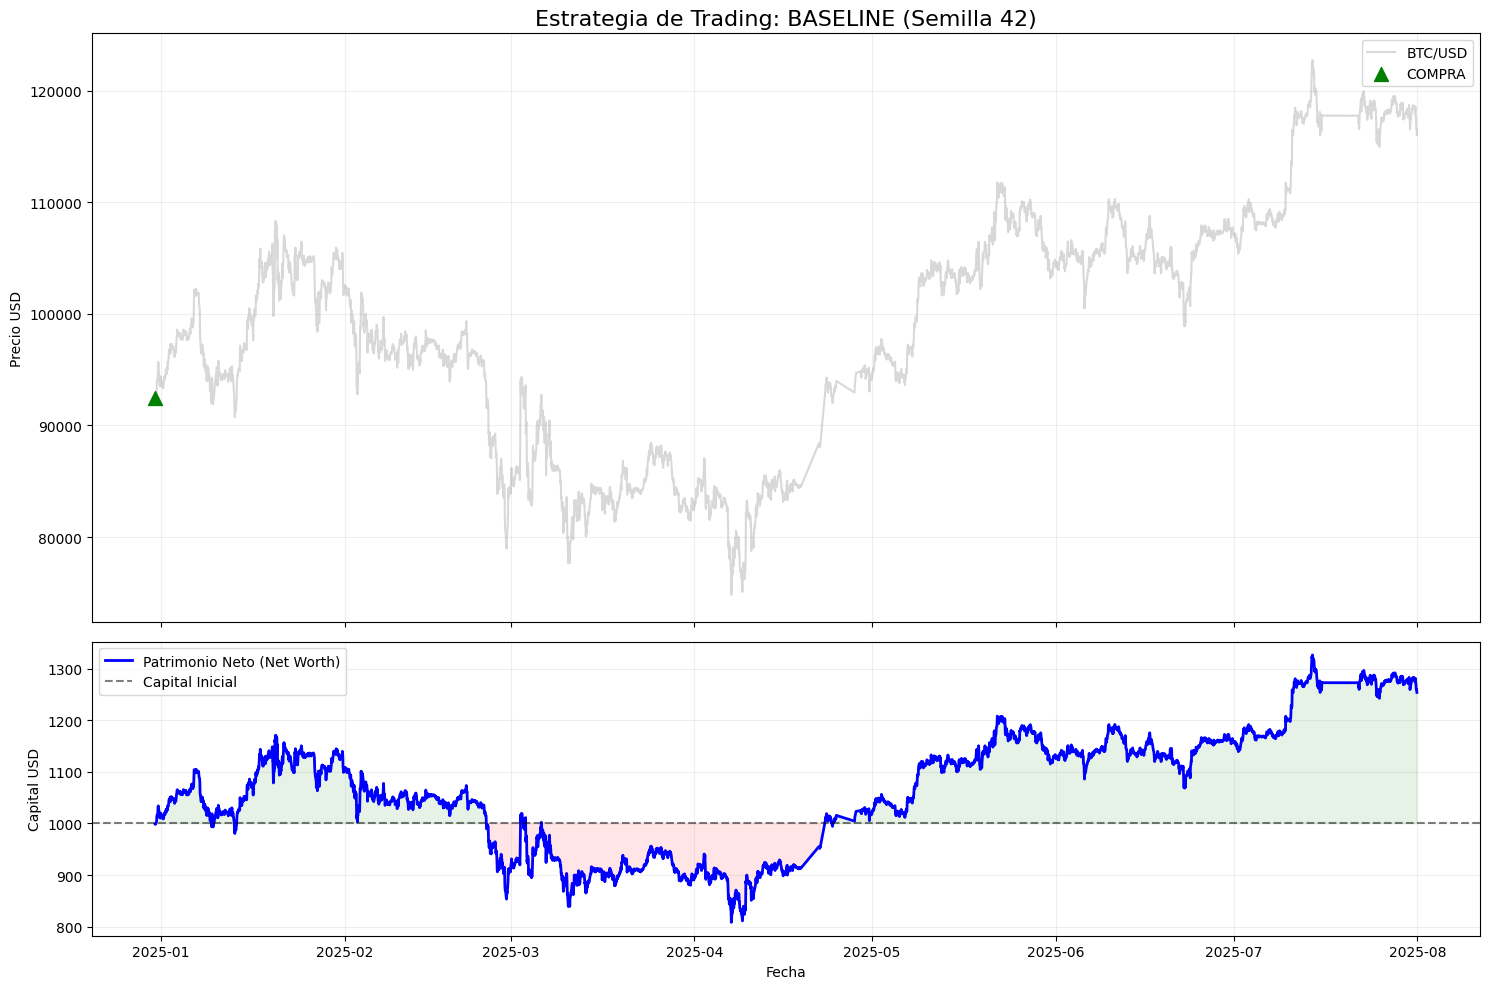


 ANALIZANDO MODELO: BASELINE | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 1
🔴 Ventas ejecutadas:  0
📊 Operaciones totales: 1
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $1253.79
📈 Retorno Total:      25.38%
----------------------------------


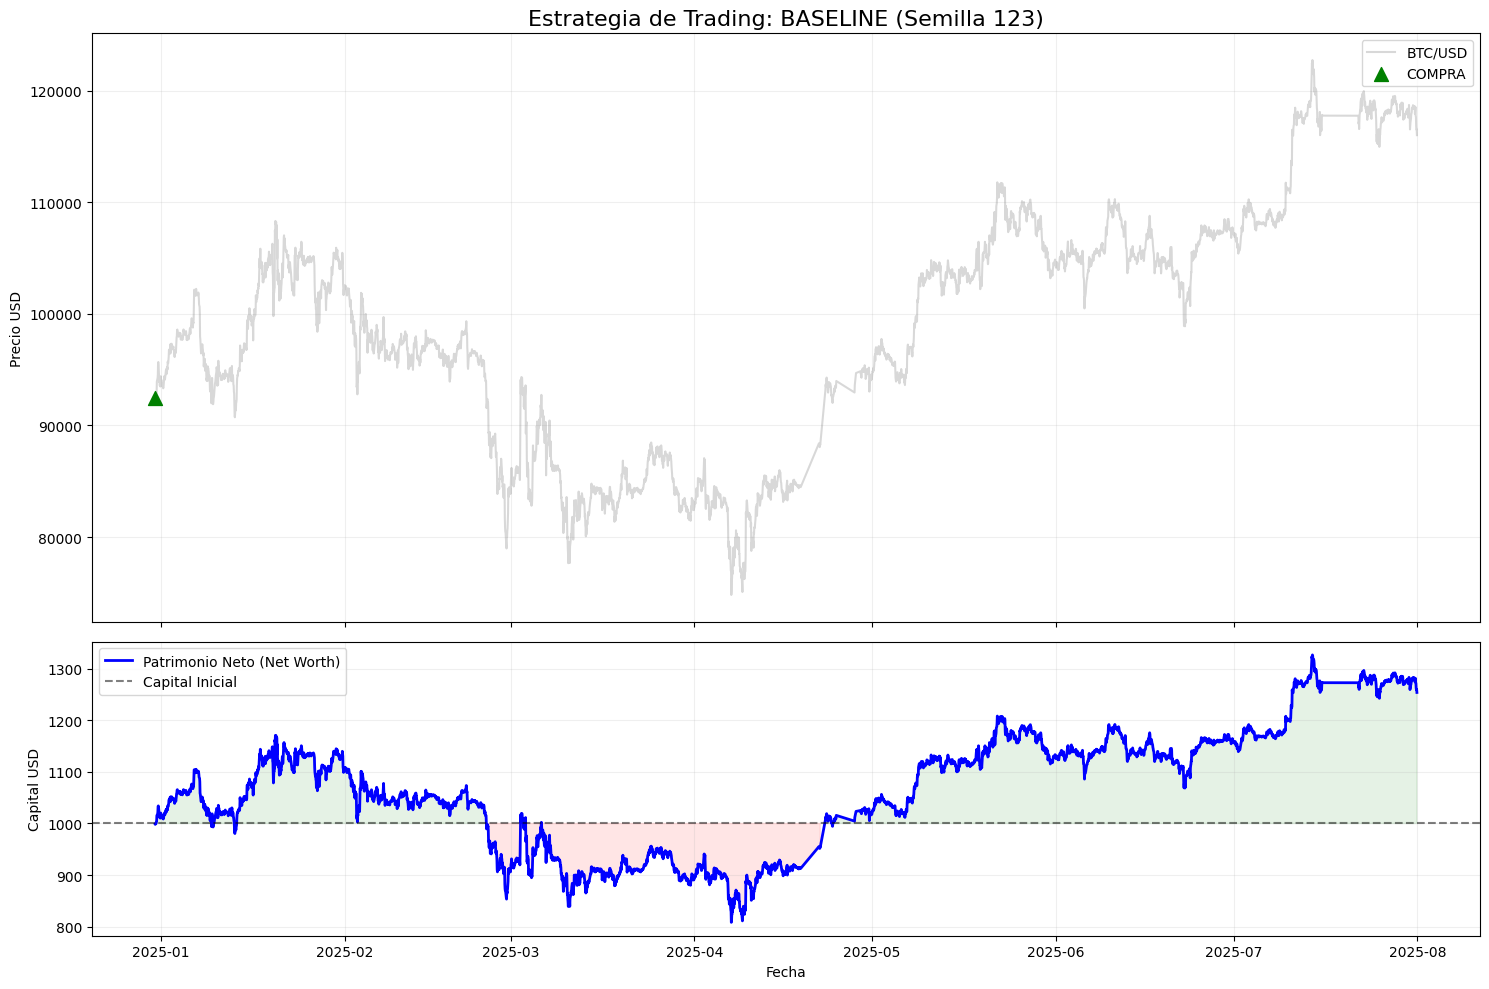


 ANALIZANDO MODELO: BASELINE | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 1
🔴 Ventas ejecutadas:  0
📊 Operaciones totales: 1
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $1253.79
📈 Retorno Total:      25.38%
----------------------------------


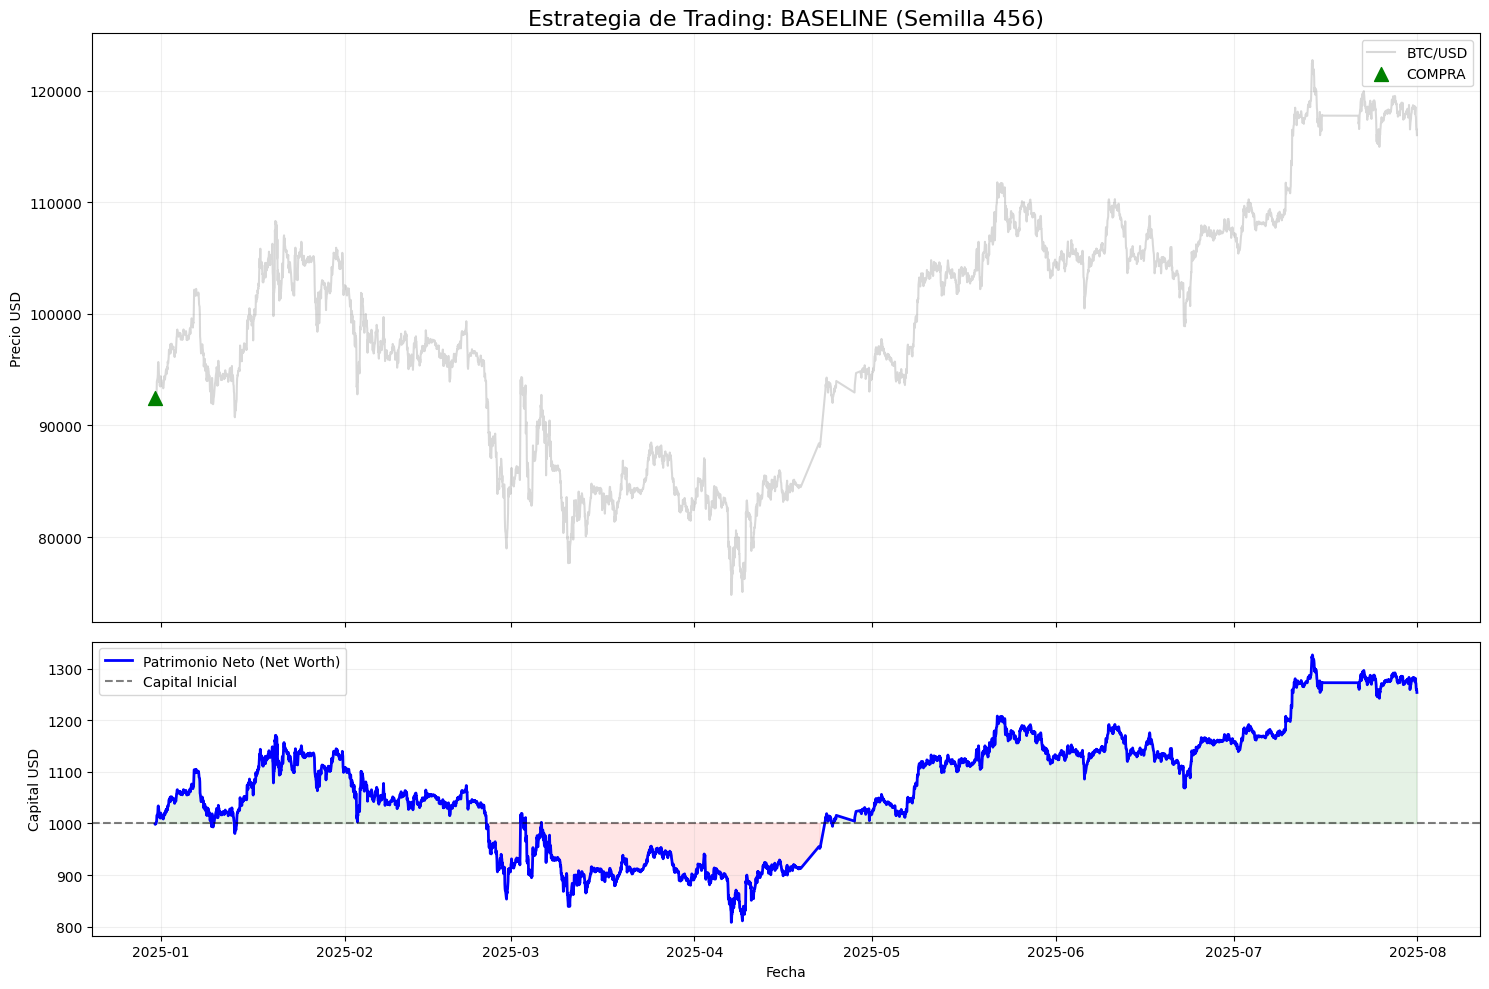


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 1100
🔴 Ventas ejecutadas:  1099
📊 Operaciones totales: 2199
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $109.43
📈 Retorno Total:      -89.06%
----------------------------------


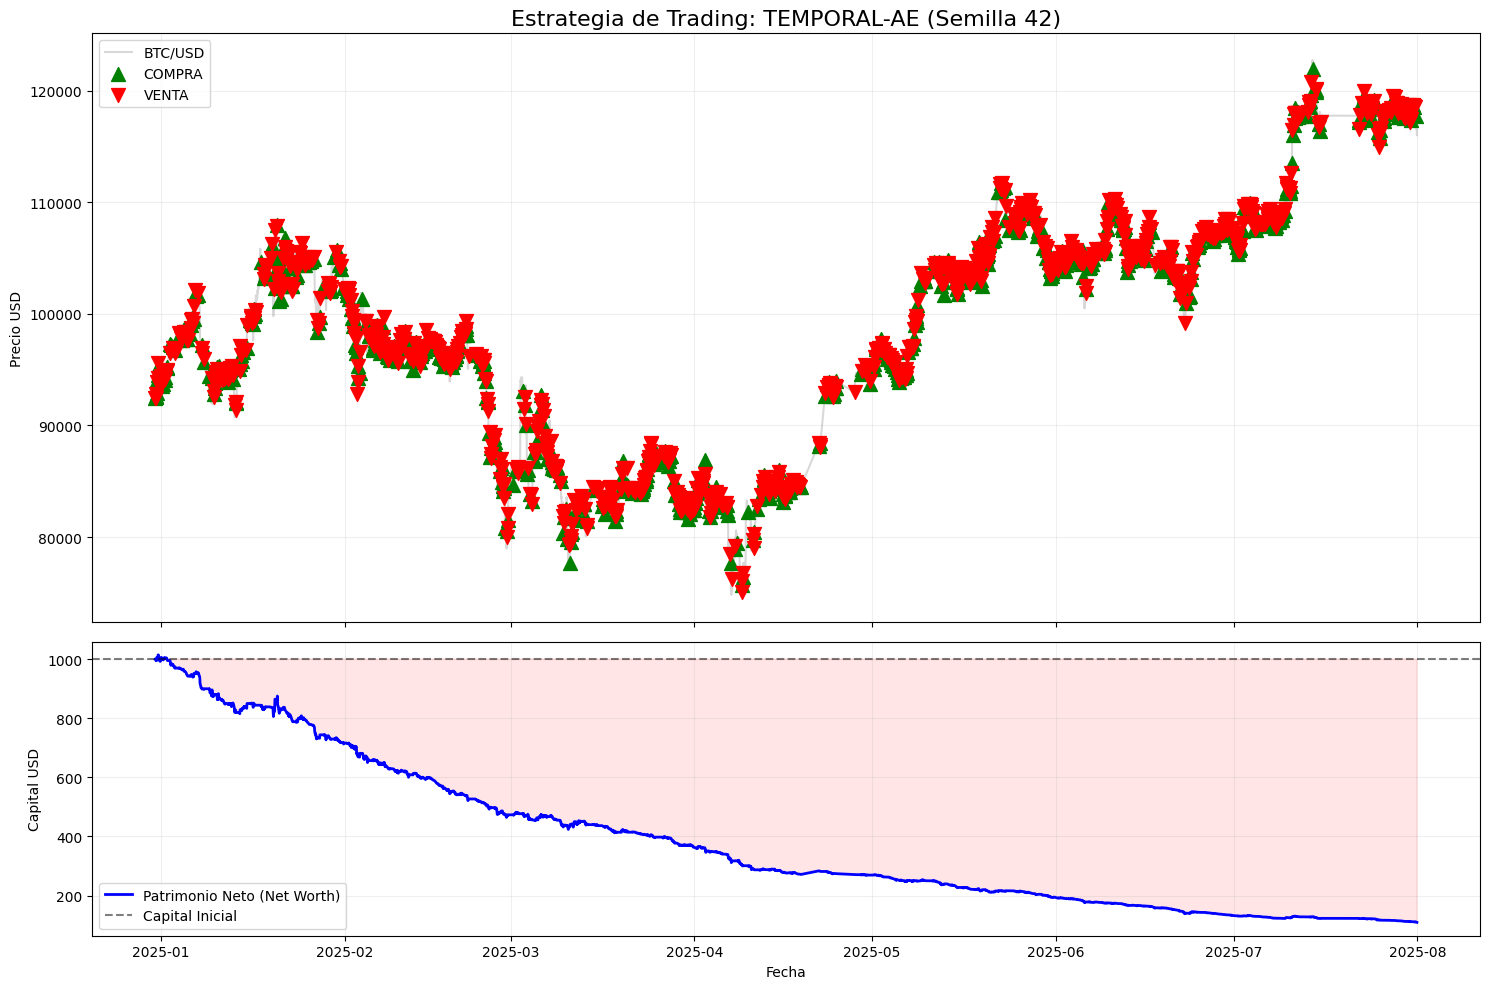


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 537
🔴 Ventas ejecutadas:  537
📊 Operaciones totales: 1074
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $357.53
📈 Retorno Total:      -64.25%
----------------------------------


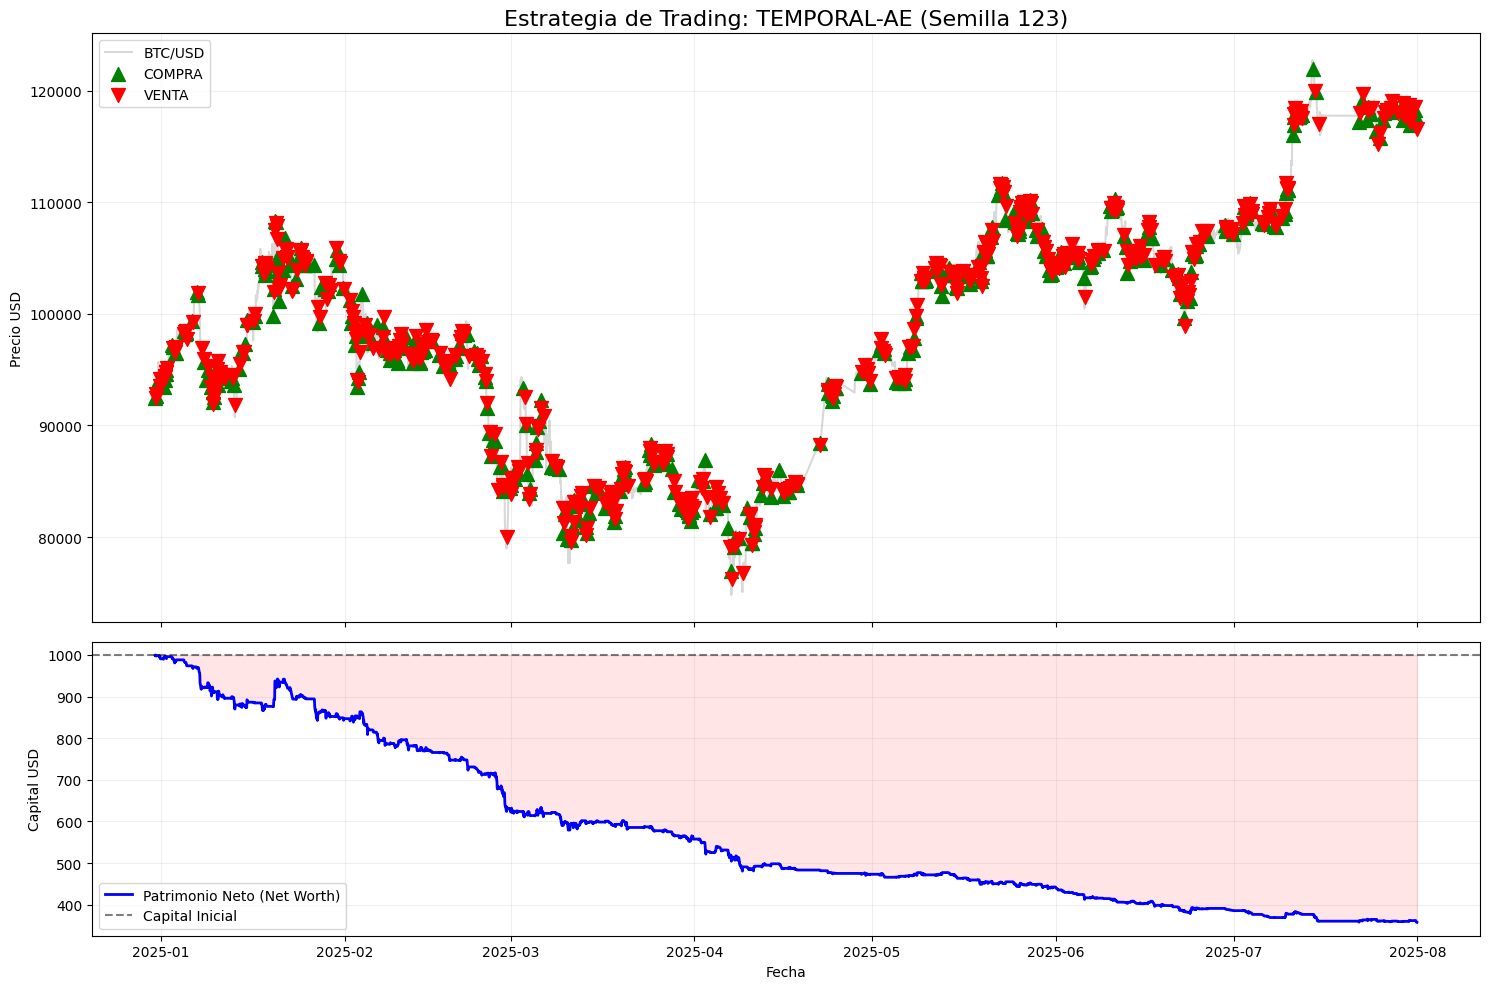


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 771
🔴 Ventas ejecutadas:  771
📊 Operaciones totales: 1542
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $206.17
📈 Retorno Total:      -79.38%
----------------------------------


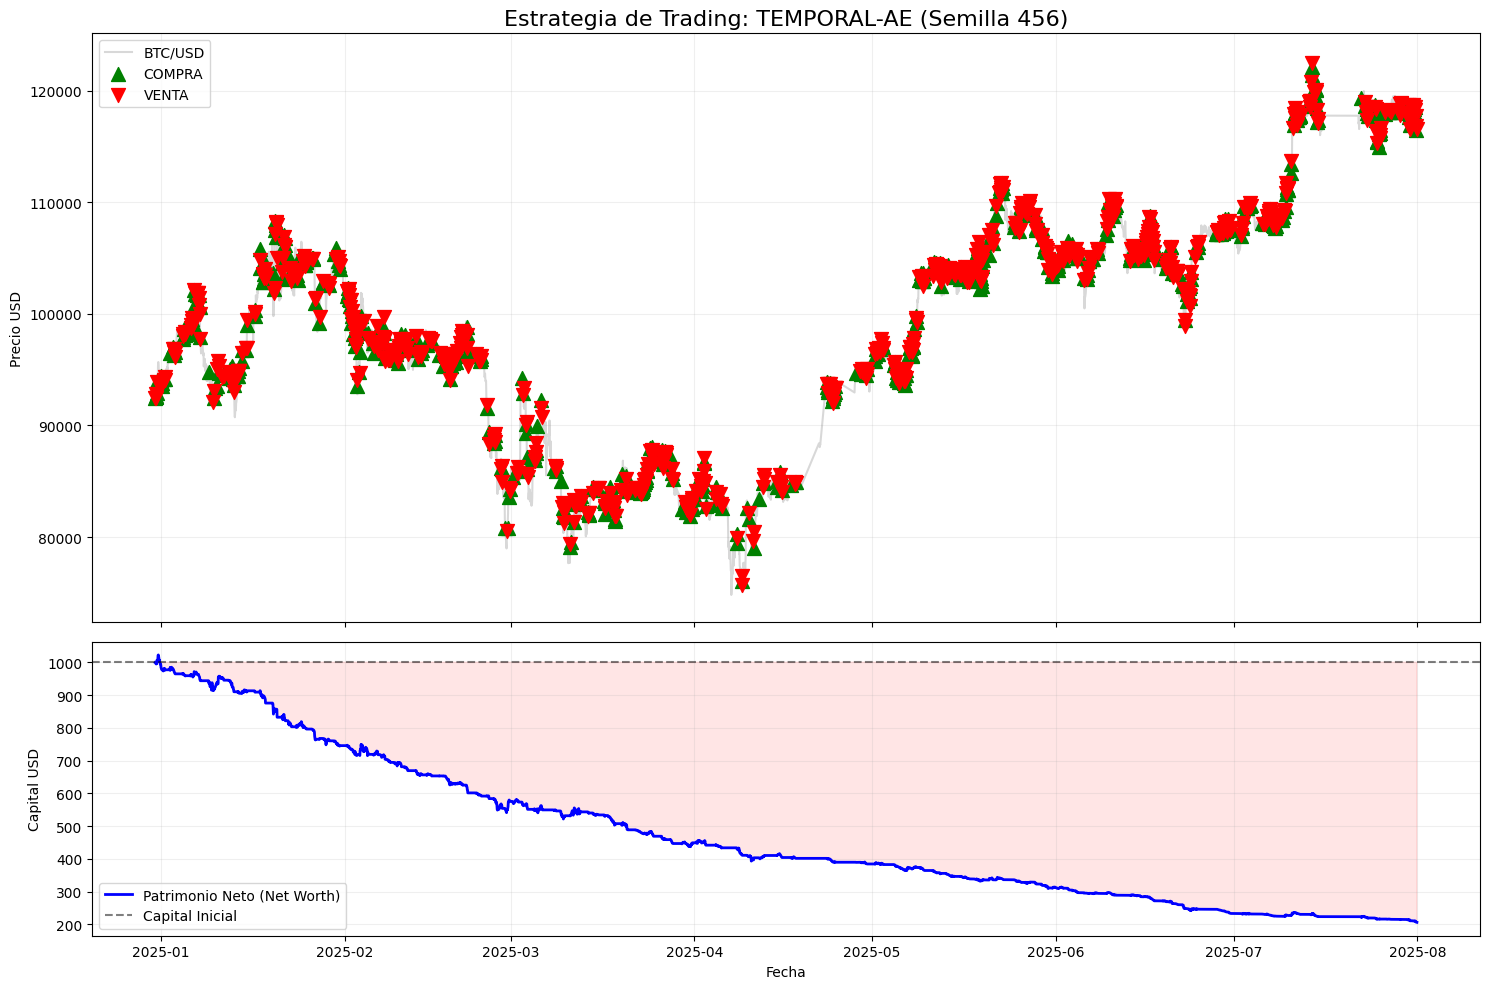


 ANALIZANDO MODELO: CPC | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 469
🔴 Ventas ejecutadas:  469
📊 Operaciones totales: 938
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $370.06
📈 Retorno Total:      -62.99%
----------------------------------


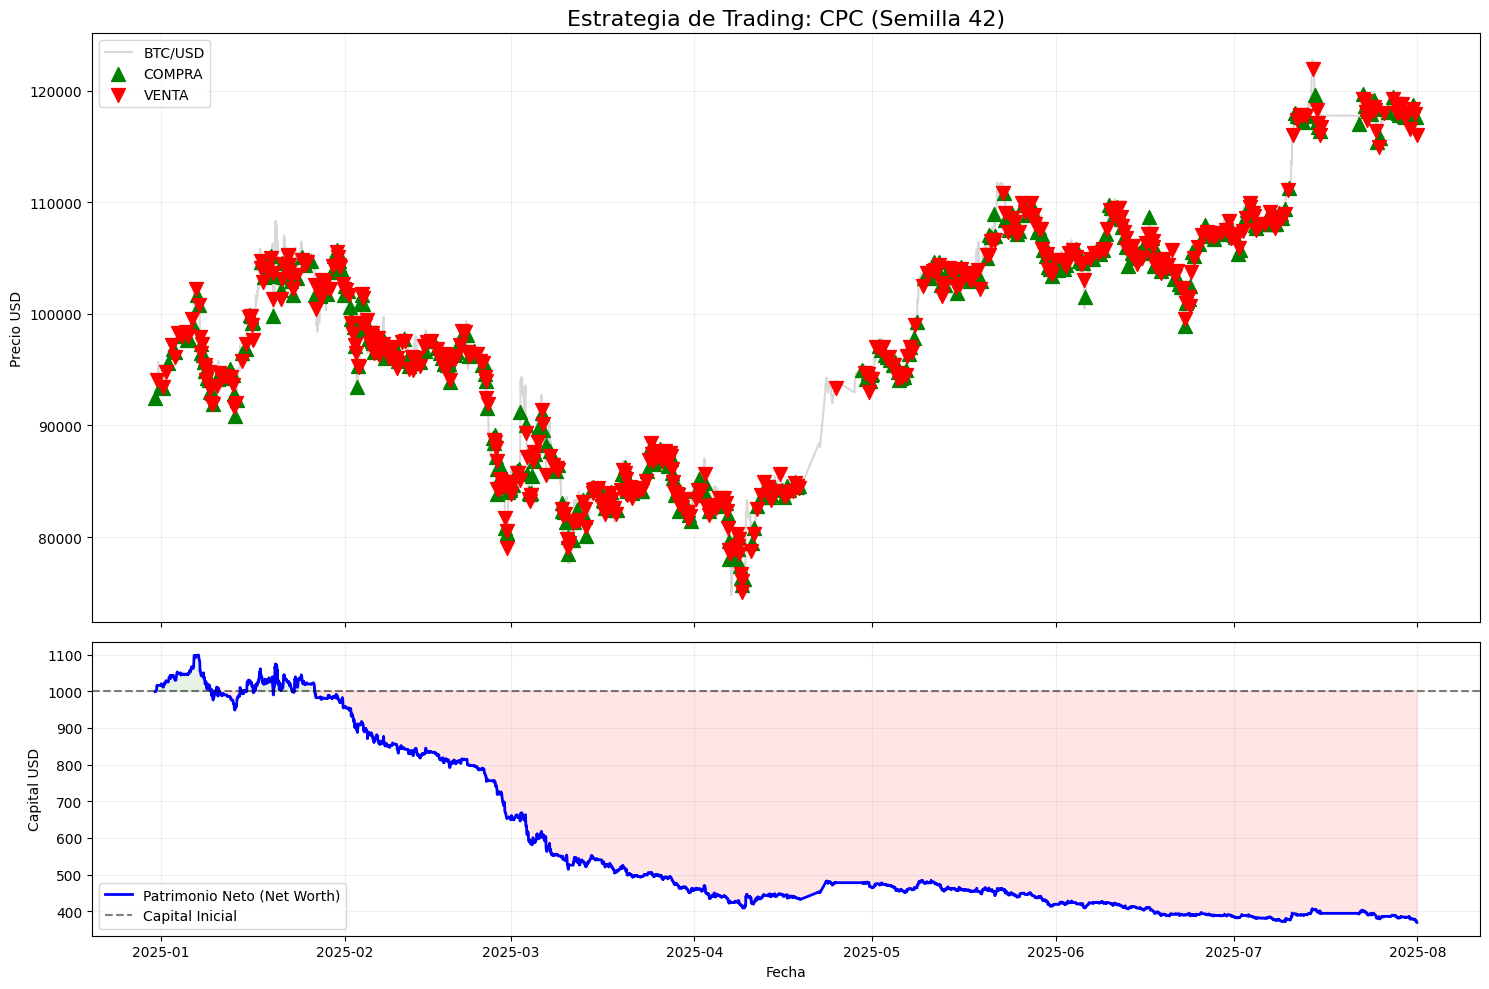


 ANALIZANDO MODELO: CPC | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 130
🔴 Ventas ejecutadas:  130
📊 Operaciones totales: 260
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $848.57
📈 Retorno Total:      -15.14%
----------------------------------


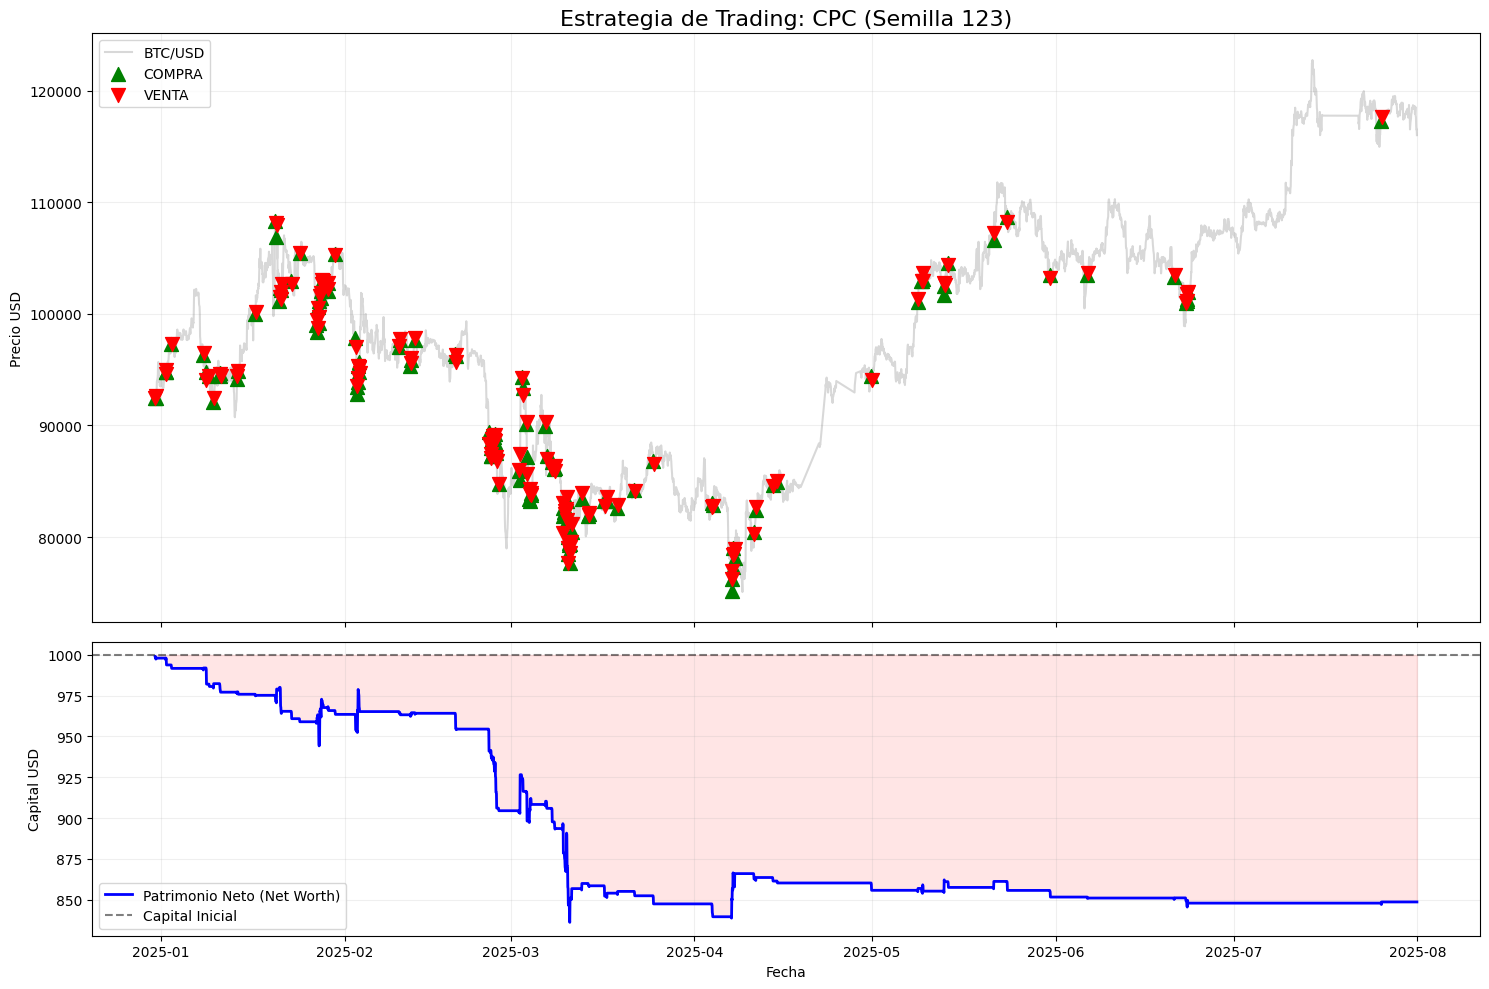


 ANALIZANDO MODELO: CPC | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 586
🔴 Ventas ejecutadas:  585
📊 Operaciones totales: 1171
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $243.80
📈 Retorno Total:      -75.62%
----------------------------------


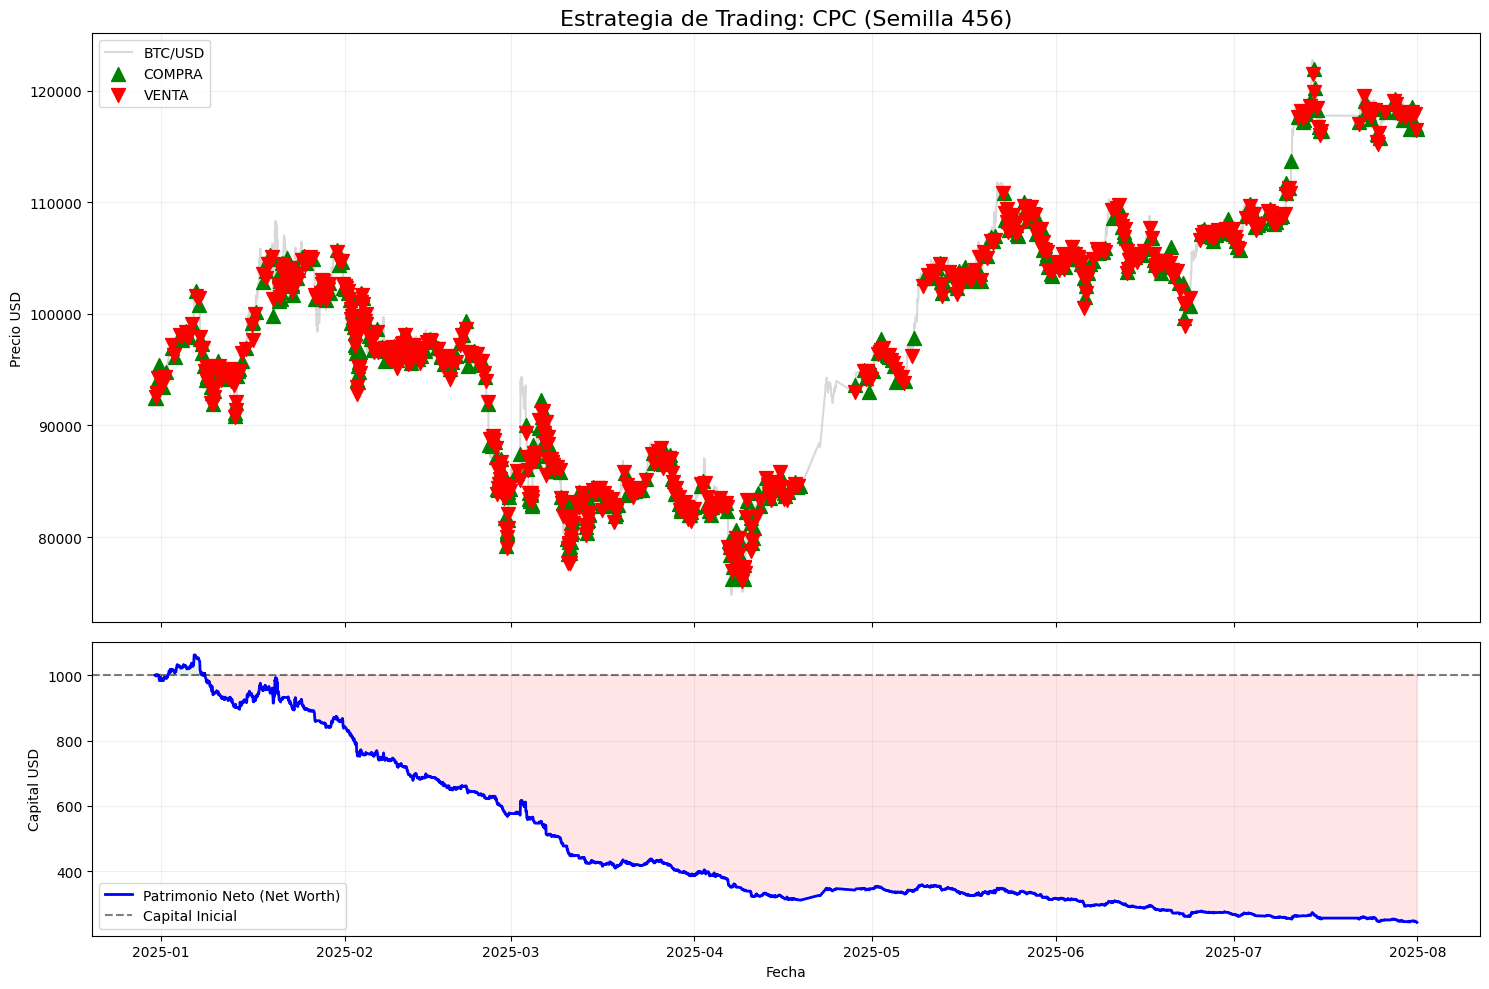


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 0
🔴 Ventas ejecutadas:  0
📊 Operaciones totales: 0
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $1000.00
📈 Retorno Total:      0.00%
----------------------------------


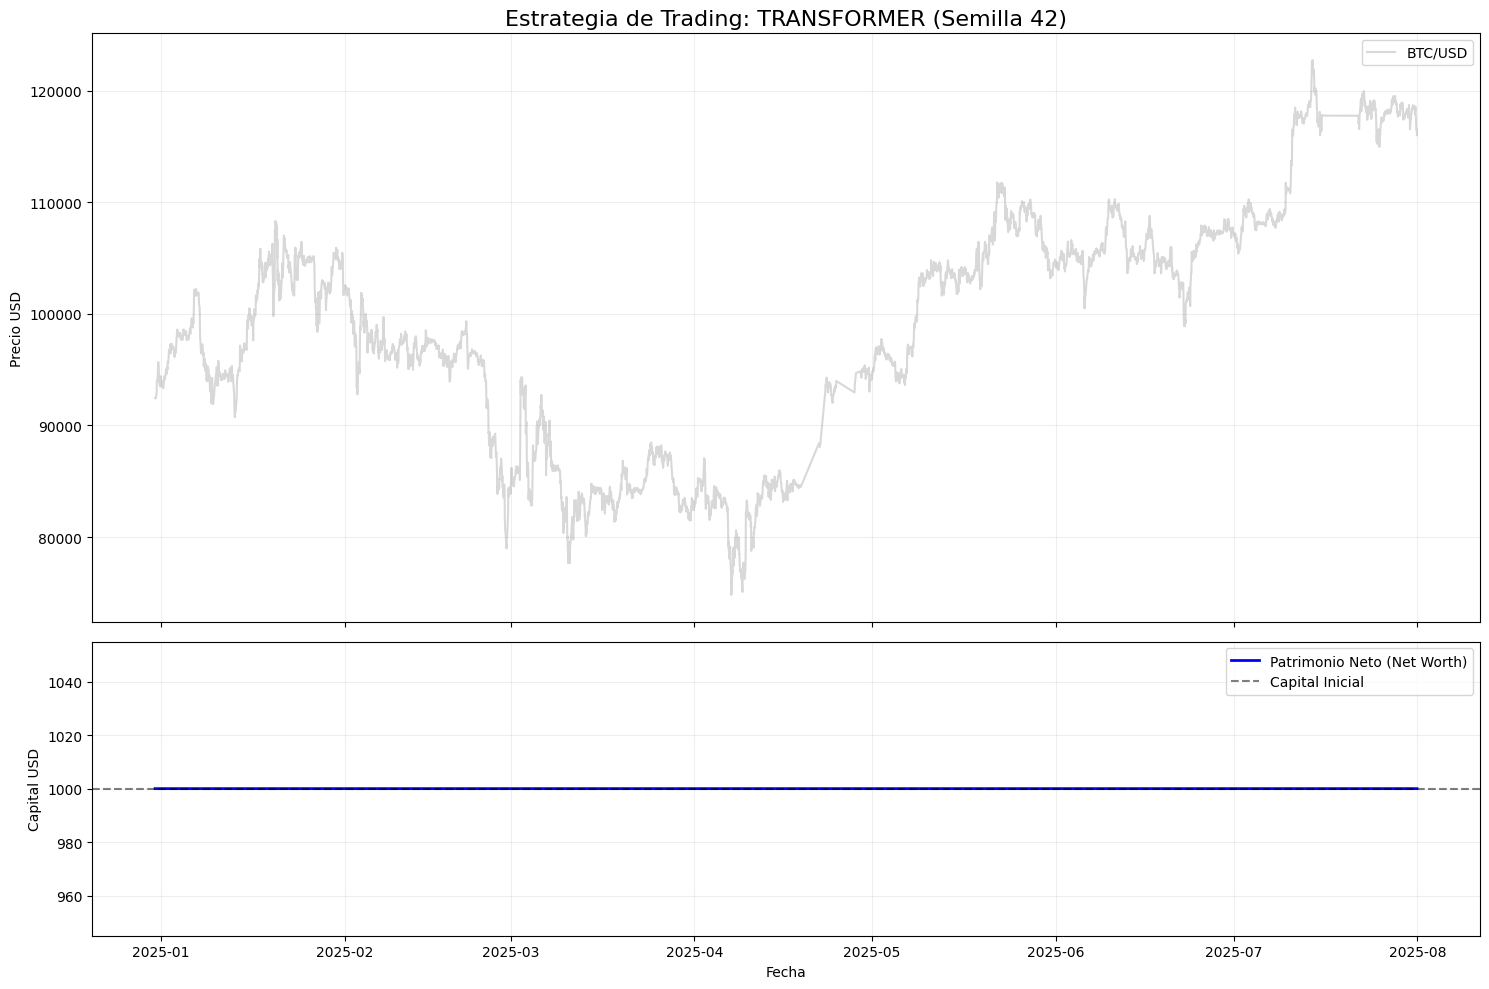


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 1
🔴 Ventas ejecutadas:  0
📊 Operaciones totales: 1
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $1195.20
📈 Retorno Total:      19.52%
----------------------------------


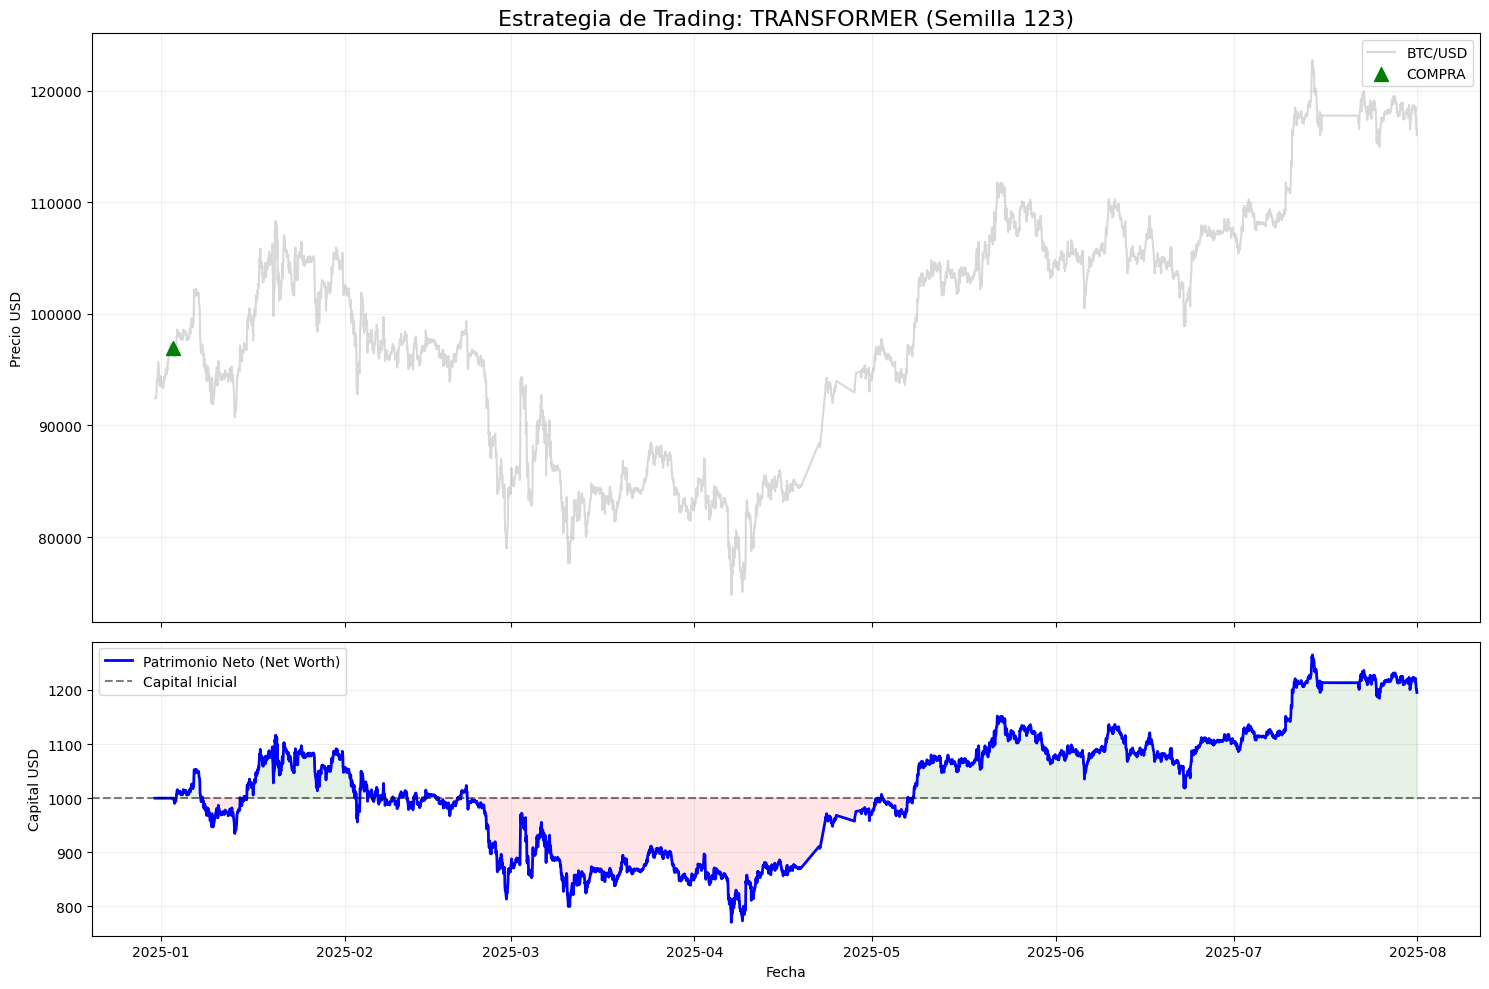


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras ejecutadas: 4
🔴 Ventas ejecutadas:  3
📊 Operaciones totales: 7
💰 Balance Inicial:    $1000.00
🏁 Balance Final:      $1104.35
📈 Retorno Total:      10.43%
----------------------------------


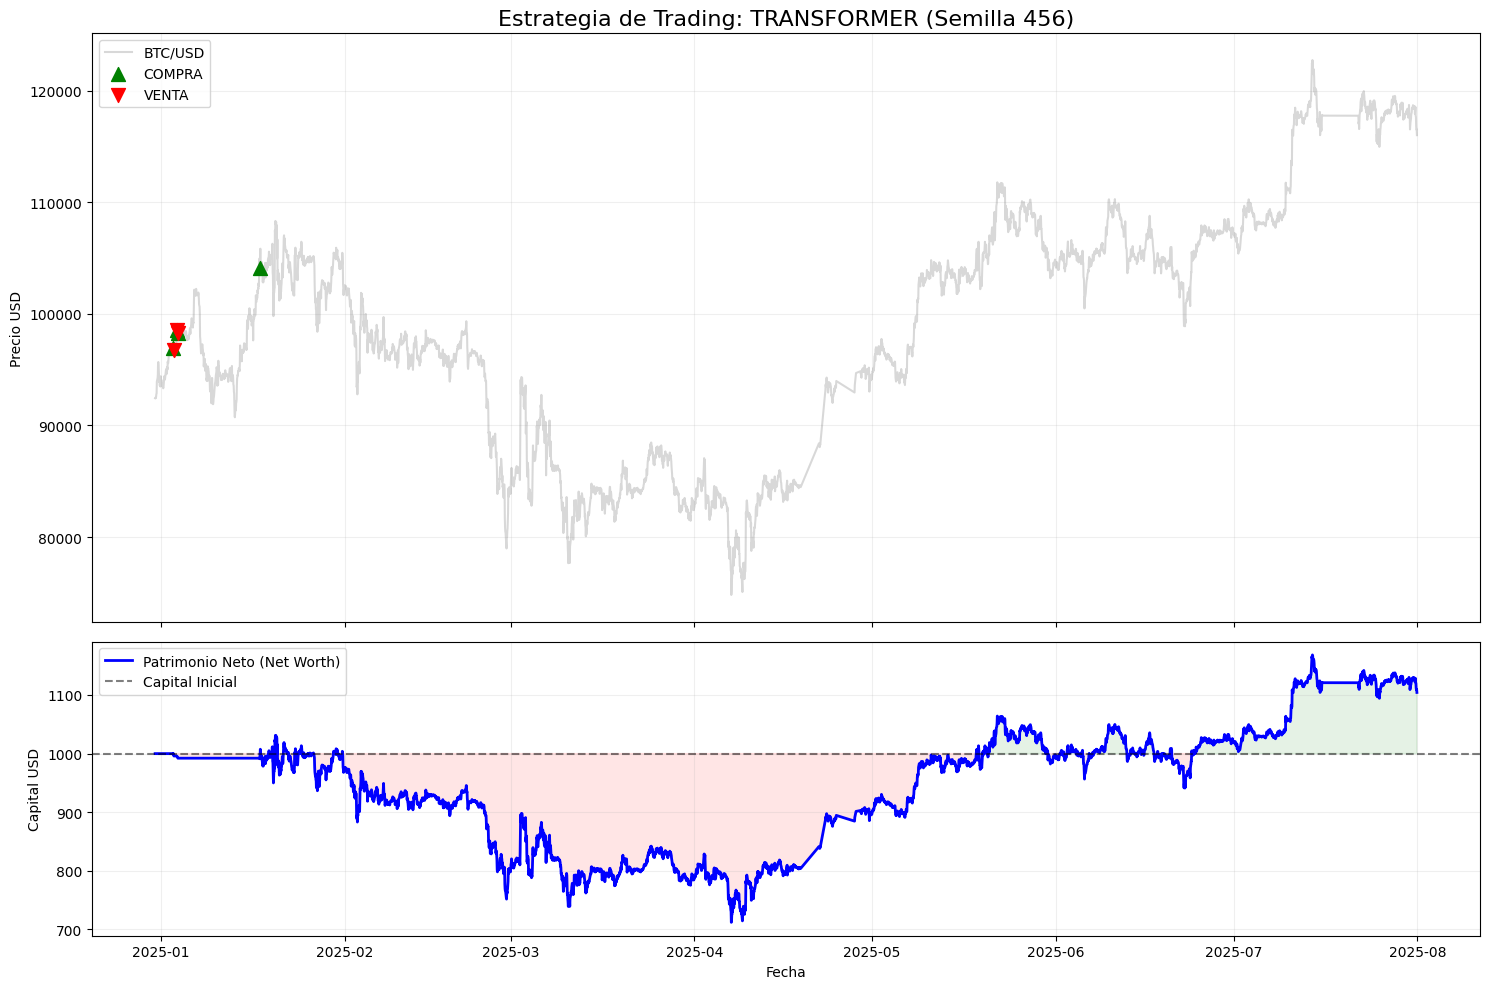

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os
from stable_baselines3 import DQN

def plot_trading_results(model_name, seed, tf="1h"):
    """
    Simula el modelo, genera gráficas de operativa y muestra resumen por pantalla.
    """
    print(f"\n" + "="*50)
    print(f" ANALIZANDO MODELO: {model_name.upper()} | SEMILLA: {seed}")
    print("="*50)

    # 1. Cargar datos (Usando los últimos 4698 pasos de validación)
    try:
        # Cargamos los datos usando la función que ya tienes definida en tu notebook
        features_all, prices_all = load_data_all_types(model_name, tf)
        
        val_size = 4698 
        df_feat_val = features_all.tail(val_size)
        df_prices_val = prices_all.tail(val_size)
        
        print(f"✅ Datos cargados: {len(df_feat_val)} velas para test.")
    except Exception as e:
        print(f"❌ Error al cargar datos: {e}")
        return

    # 2. Cargar el Agente Entrenado
    model_path = f"../RL_outputs/models/dqn_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el archivo: {model_path}")
        return
    
    agent = DQN.load(model_path)

    # 3. Simulación en el entorno
    # Nota: Usamos los valores por defecto si no están definidos
    init_bal = 1000
    fee_rate = 0.001
    env = SRLTradingEnv(df_feat_val, df_prices_val, initial_balance=init_bal, fee=fee_rate)
    
    obs, _ = env.reset()
    done = False
    
    net_worths = []
    actions = []
    
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        net_worths.append(info.get('net_worth', init_bal)) 
        actions.append(action)

    # 4. Lógica de detección de operaciones (Entradas y Salidas reales)
    buys_idx = []
    sells_idx = []
    current_position = 0 # 0: Cash, 1: Long
    
    for i, act in enumerate(actions):
        if act == 1 and current_position == 0:
            buys_idx.append(i)
            current_position = 1
        elif act == 0 and current_position == 1:
            sells_idx.append(i)
            current_position = 0

    # 5. Resumen por pantalla
    total_ops = len(buys_idx) + len(sells_idx)
    retorno_final = ((net_worths[-1] / init_bal) - 1) * 100
    
    print(f"\n--- ESTADÍSTICAS DE OPERATIVA ---")
    print(f"🔵 Compras ejecutadas: {len(buys_idx)}")
    print(f"🔴 Ventas ejecutadas:  {len(sells_idx)}")
    print(f"📊 Operaciones totales: {total_ops}")
    print(f"💰 Balance Inicial:    ${init_bal:.2f}")
    print(f"🏁 Balance Final:      ${net_worths[-1]:.2f}")
    print(f"📈 Retorno Total:      {retorno_final:.2f}%")
    print("-" * 34)

    # 6. Generación de Gráficas
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    prices = df_prices_val.values[:len(net_worths)]
    dates = df_prices_val.index[:len(net_worths)]

    # Subplot 1: Precio y flechas
    ax1.plot(dates, prices, color='gray', alpha=0.3, label='BTC/USD')
    if buys_idx:
        ax1.scatter(dates[buys_idx], prices[buys_idx], marker='^', color='green', s=100, label='COMPRA', zorder=5)
    if sells_idx:
        ax1.scatter(dates[sells_idx], prices[sells_idx], marker='v', color='red', s=100, label='VENTA', zorder=5)
    
    ax1.set_title(f"Estrategia de Trading: {model_name.upper()} (Semilla {seed})", fontsize=16)
    ax1.set_ylabel("Precio USD")
    ax1.legend(loc='best')
    ax1.grid(alpha=0.2)

    # Subplot 2: Evolución del Capital
    ax2.plot(dates, net_worths, color='blue', lw=2, label='Patrimonio Neto (Net Worth)')
    ax2.axhline(y=init_bal, color='black', linestyle='--', alpha=0.5, label='Capital Inicial')
    
    # Sombreado de beneficio/pérdida
    net_worths_arr = np.array(net_worths)
    ax2.fill_between(dates, init_bal, net_worths_arr, where=(net_worths_arr >= init_bal), color='green', alpha=0.1)
    ax2.fill_between(dates, init_bal, net_worths_arr, where=(net_worths_arr < init_bal), color='red', alpha=0.1)
    
    ax2.set_ylabel("Capital USD")
    ax2.set_xlabel("Fecha")
    ax2.legend(loc='best')
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
# Lanza los que quieras comparar:

plot_trading_results('baseline', 42)
plot_trading_results('baseline', 123)
plot_trading_results('baseline', 456)

plot_trading_results('temporal-ae', 42)
plot_trading_results('temporal-ae', 123)
plot_trading_results('temporal-ae', 456)

plot_trading_results('cpc', 42)
plot_trading_results('cpc', 123)
plot_trading_results('cpc', 456)

plot_trading_results('transformer', 42)
plot_trading_results('transformer', 123)
plot_trading_results('transformer', 456)

In [16]:
# Celda de verificación rápida
print(f"Pasos totales en validación: {len(history)}")
print(f"Balance inicial: {INITIAL_BALANCE}")
print(f"Balance final: {history[-1]:.2f}")

if history[0] == history[-1]:
    print("ALERTA: El balance no ha cambiado. El agente no ha abierto ninguna operación.")
else:
    print("ÉXITO: El balance ha cambiado. El agente está operando con los embeddings.")

Pasos totales en validación: 4697
Balance inicial: 1000
Balance final: 1104.35
ÉXITO: El balance ha cambiado. El agente está operando con los embeddings.
